## Supervised Learning - Building a Student Performance Classification System


#### The aim of this project is to predict how likely a student is to pass. 

This project is a classification supervised learning problem because the variable to predict, i.e. if a student graduates or fails to graduate, is categorical. On this case this a dichotomous categorical variable where the only two possible values are "pass" or "fail".

### Overview:

1.Read the problem statement.

2.Get the dataset.

3.Drop missing values.

4.Transform Data

5.Drop variables with less variance

6.Encode all categorical variables to numerical

7.Convert the continuous values of grades into classes

8.Apply the models.

9.Visualization

10.Provide insights.

11.Training and testing data split

12.Model Implementation and Testing the Accuracy

## Problem Statement 

Using Logistic Regression **predict the performance of student**. The classification goal is to predict whether the student will pass or fail.

## Dataset 

This data approach student achievement in secondary education of two Portuguese schools. The data attributes include student grades, demographic, social and school related features) and it was collected by using school reports and questionnaires. Two datasets are provided regarding the performance in Mathematics.

**Source:** https://archive.ics.uci.edu/ml/datasets/Student+Performance


## Importing Libraries

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

## Exploring the Data

## Question 1 - Read Dataset, Print Columns and Drop missing values


#### Answer:

#In case you are working in Google Colab, Upload the csv file to colab.
from google.colab import files

uploaded = files.upload()

In [232]:
# Read dataset using pandas and print few rows
# Hint: Read the dataset file using pandas.read_csv(). Take care about the delimiter.
df=pd.read_csv("C:\AIML\Supervised Learning\LAB\students-data.csv", delimiter=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [233]:
# Print the columns in the dataframe
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [234]:
#Let's see column column info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
school        395 non-null object
sex           395 non-null object
age           395 non-null int64
address       395 non-null object
famsize       395 non-null object
Pstatus       395 non-null object
Medu          395 non-null int64
Fedu          395 non-null int64
Mjob          395 non-null object
Fjob          395 non-null object
reason        395 non-null object
guardian      395 non-null object
traveltime    395 non-null int64
studytime     395 non-null int64
failures      395 non-null int64
schoolsup     395 non-null object
famsup        395 non-null object
paid          395 non-null object
activities    395 non-null object
nursery       395 non-null object
higher        395 non-null object
internet      395 non-null object
romantic      395 non-null object
famrel        395 non-null int64
freetime      395 non-null int64
goout         395 non-null int64
Dalc          395 no

In [235]:
# Drop missing values
# Hint: Set the index name of the dataframe to "number". Check sample of data to drop if any missing values are there

#There are no missing values in the dataframe and hence ther eis no need to drop null values.
print("Are there any missing values:", df.isnull().values.any() )

print(pd.DataFrame( df.isnull().sum(), columns= ['Number of missing values']))

print("Total Number of missing values:", df.isnull().sum().sum())

#Set the index name of the dataframe to "number"
df.index.name='number'

#Check if the index is changed to Number
df.head(5)

Are there any missing values: False
            Number of missing values
school                             0
sex                                0
age                                0
address                            0
famsize                            0
Pstatus                            0
Medu                               0
Fedu                               0
Mjob                               0
Fjob                               0
reason                             0
guardian                           0
traveltime                         0
studytime                          0
failures                           0
schoolsup                          0
famsup                             0
paid                               0
activities                         0
nursery                            0
higher                             0
internet                           0
romantic                           0
famrel                             0
freetime                           0
go

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
number,,,,,,,,,,,,,,,,,,,,,
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Transform Data

## Question 2 - Print all the attribute names which are not numerical.

**Hint:** check **select_dtypes()** and its **include** and **exclude** parameters.**

#### Answer:

In [236]:
#Print categorical attributes using include parameter
df.select_dtypes(include='object').columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

In [237]:
#Print categorical attributes using exclude parameter
df.select_dtypes(exclude='number').columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

In [238]:
df.shape

(395, 33)

## Question 3 - Drop variables with less variance

*Find the variance of each numerical independent variable and drop whose variance is less than 1.*

In [239]:
#Find the variance for numeric columns.
df.var()

age            1.628285
Medu           1.198445
Fedu           1.184180
traveltime     0.486513
studytime      0.704324
failures       0.553017
famrel         0.803997
freetime       0.997725
goout          1.239388
Dalc           0.793420
Walc           1.658678
health         1.932944
absences      64.049541
G1            11.017053
G2            14.148917
G3            20.989616
dtype: float64

In [240]:
from pandas.api.types import is_string_dtype
from pandas.api.types import is_numeric_dtype
from pandas.api.types import is_object_dtype

for idx in df.columns:
        if(is_numeric_dtype(df.dtypes[idx])and df[idx].var() < 1):
            print(' Attribute name - ',idx, ' has variance less than 1') 
            df.drop(idx,axis=1,inplace =True)

 Attribute name -  traveltime  has variance less than 1
 Attribute name -  studytime  has variance less than 1
 Attribute name -  failures  has variance less than 1
 Attribute name -  famrel  has variance less than 1
 Attribute name -  freetime  has variance less than 1
 Attribute name -  Dalc  has variance less than 1


In [241]:
df.shape

(395, 27)

#### Variables with less variance are almost same for all the records. Hence, they do not contribute much for classification.

## Question 4 - Encode all categorical variables to numerical

Take the list of categorical attributes(from the above result) and convert them into neumerical variables. After that, print the head of dataframe and check the values.

**Hint:** check **sklearn LabelEncoder()**

#### Answer:

In [242]:
#df_encoded = df.apply(LabelEncoder().fit_transform)
df_cat=df.select_dtypes(include='object')
df_cat.head()

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
number,,,,,,,,,,,,,,,,,
0,GP,F,U,GT3,A,at_home,teacher,course,mother,yes,no,no,no,yes,yes,no,no
1,GP,F,U,GT3,T,at_home,other,course,father,no,yes,no,no,no,yes,yes,no
2,GP,F,U,LE3,T,at_home,other,other,mother,yes,no,yes,no,yes,yes,yes,no
3,GP,F,U,GT3,T,health,services,home,mother,no,yes,yes,yes,yes,yes,yes,yes
4,GP,F,U,GT3,T,other,other,home,father,no,yes,yes,no,yes,yes,no,no


In [243]:
#Using Label Encoder, convert the categorical to numeric values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in range(0,df.shape[1]):
    if df.dtypes[i]=='object':
        df[df.columns[i]] = le.fit_transform(df[df.columns[i]])

In [244]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,goout,Walc,health,absences,G1,G2,G3
number,,,,,,,,,,,,,,,,,,,,,
0,0,0,18,1,0,0,4,4,0,4,...,1,0,0,4,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,1,1,0,3,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,1,1,0,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,1,1,1,2,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,1,0,0,2,2,5,4,6,10,10


In [245]:
#Another approach to perform LE on dataset.
L = df.select_dtypes(include='object').columns
df.apply(lambda x: class_le.fit_transform(x) if (x.name in L) else x)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,goout,Walc,health,absences,G1,G2,G3
number,,,,,,,,,,,,,,,,,,,,,
0,0,0,18,1,0,0,4,4,0,4,...,1,0,0,4,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,1,1,0,3,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,1,1,0,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,1,1,1,2,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,1,0,0,2,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,1,1,20,1,1,0,2,2,3,3,...,1,0,0,4,5,4,11,9,9,9
391,1,1,17,1,1,1,3,1,3,3,...,1,1,0,5,4,2,3,14,16,16
392,1,1,21,0,0,1,1,1,2,2,...,1,0,0,3,3,3,3,10,8,7


## Question 5 - Convert the continuous values of grades into classes

*Consider the values in G1, G2 and G3 with >= 10 as pass(1) and < 10 as fail(0) and encode them into binary values. Print head of dataframe to check the values.*

#### Answer:

In [246]:
#Consider the values in G1, G2 and G3 with >= 10 as pass(1) and < 10 as fail(0) and encode them into binary values
for col in ['G1','G2','G3']:
     df[col]=df[col].apply(lambda x: 1 if (x>=10) else 0)

In [248]:
#Print head of dataframe
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,goout,Walc,health,absences,G1,G2,G3
number,,,,,,,,,,,,,,,,,,,,,
0,0,0,18,1,0,0,4,4,0,4,...,1,0,0,4,1,3,6,0,0,0
1,0,0,17,1,0,1,1,1,0,2,...,1,1,0,3,1,3,4,0,0,0
2,0,0,15,1,1,1,1,1,0,2,...,1,1,0,2,3,3,10,0,0,1
3,0,0,15,1,0,1,4,2,1,3,...,1,1,1,2,1,5,2,1,1,1
4,0,0,16,1,0,1,3,3,2,2,...,1,0,0,2,2,5,4,0,1,1


In [249]:
df.G1.value_counts()

1    253
0    142
Name: G1, dtype: int64

In [250]:
G2=df.G2.value_counts()
G2

1    249
0    146
Name: G2, dtype: int64

In [251]:
G3=df.G3.value_counts()
G3

1    265
0    130
Name: G3, dtype: int64

## Apply the models.

## Question 6 - Separate Feature and Target
*Consider G3 is the target attribute and remaining all attributes as features to predict G3. Now, separate features and target into separate dataframes and name them X and y respectively.*

In [252]:
# Target values are G3
y=df['G3']

# Feature set is remaining features
X=df.drop('G3',axis=1)

print(X.shape, y.shape)

(395, 26) (395,)


## Visualization

## Question 7 - Plot G2 and G3 and give your understanding on relation between both variables.

* Hint:Bar plot to compare counts of '0' and '1' in G2 and G3

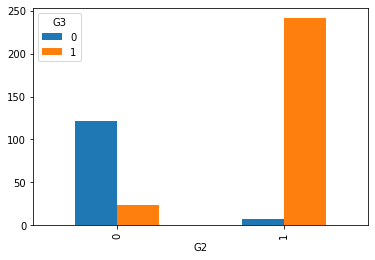

In [253]:
pd.crosstab(df.G2, df.G3).plot(kind='bar')

In [116]:
pd.crosstab(df.G2, df.G3)

G3,0,1
G2,,
0,122,24
1,8,241


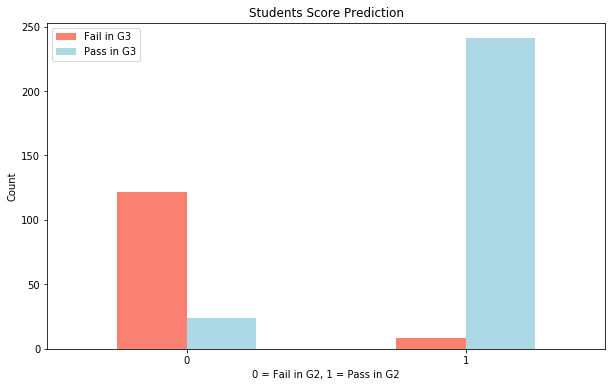

In [254]:
pd.crosstab(df.G2, df.G3).plot(kind="bar", figsize=(10, 6),
                                    color=["salmon", "lightblue"]);
plt.title("Students Score Prediction")
plt.xlabel("0 = Fail in G2, 1 = Pass in G2")
plt.ylabel("Count")
plt.legend(["Fail in G3", "Pass in G3"]);
plt.xticks(rotation=0);


The G3 depends a great deal on the G2. Thus, the G2 can be a good predictor of the outcome variable.


## Question 8 - Plot the number of students in each school and number of students with different ages in separate plots.

* Hint: Bar plots using unique value counts

In [255]:
df['school'].value_counts()

0    349
1     46
Name: school, dtype: int64

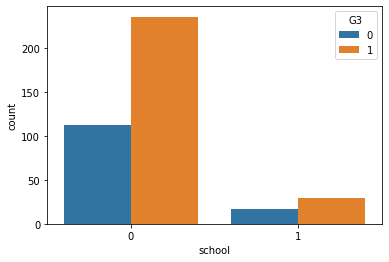

In [256]:
sns.countplot(x="school",  data=df, hue='G3')

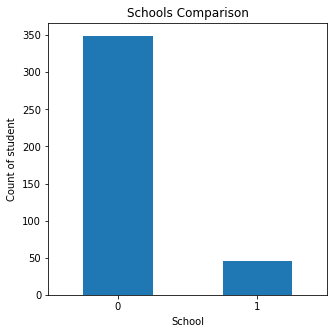

In [257]:
df['school'].value_counts().plot(kind='bar', figsize=(5, 5), rot=0)
plt.xlabel("School", labelpad=5)
plt.ylabel("Count of student", labelpad=5)
plt.title("Schools Comparison", y=1);

In [258]:
df['age'].value_counts()

16    104
17     98
18     82
15     82
19     24
20      3
22      1
21      1
Name: age, dtype: int64

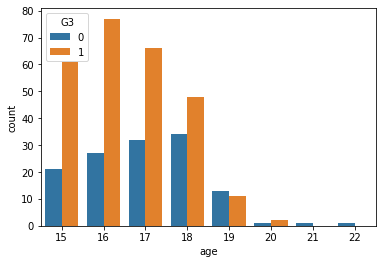

In [259]:
sns.countplot(x="age",  data=df, hue='G3')

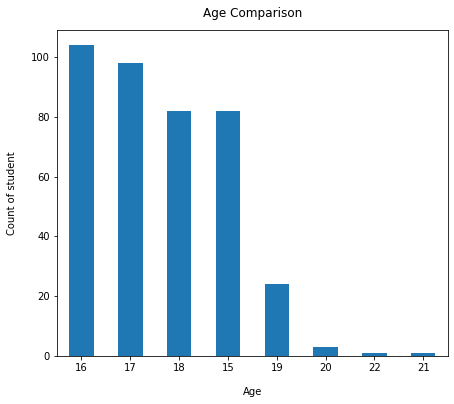

In [122]:
df['age'].value_counts().plot(kind='bar', figsize=(7, 6), rot=0)
plt.xlabel("Age", labelpad=14)
plt.ylabel("Count of student", labelpad=14)
plt.title("Age Comparison", y=1.02);

## Question 9 - Training and Testing data split

*So far, you have converted all categorical features into numeric values. Now, split the data into training and test sets with training size of 300 records. Print the number of train and test records.*

**Hint:** check **train_test_split()** from **sklearn**

#### Answer:

In [260]:
from sklearn.model_selection import  train_test_split
# Set the number of training points
#num_train = 300

# Set the number of testing points
#num_test = 95

# Shuffle and split the dataset into the number of training and testing points above

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=95,train_size=300,random_state=20)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 300 samples.
Testing set has 95 samples.


## Question 10 - Model Implementation and Testing the Accuracy

*Build a **LogisticRegression, Naive Bayes and KNN** classifier using **fit()** and **predict()** functions in sklearn. Print Accuracy and F1 score of Training and Test sets.*

#### Answer:

In [261]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [262]:
import warnings
warnings.simplefilter('ignore')

Logistic Regression

In [263]:
lr = LogisticRegression()
sc=StandardScaler()
scaledX_train = sc.fit_transform(X_train)
scaledX_test = sc.transform(X_test)
lr.fit(scaledX_train,y_train)
predicted_train = lr.predict(scaledX_train)
predicted_test = lr.predict(scaledX_test)

In [264]:
print("The Training Accuracy - LR: ", lr.score(scaledX_train,y_train))
print("The Testing Accuracy - LR: ", lr.score(scaledX_test,y_test))
print("The F1 score Training - LR: ", f1_score(y_train, predicted_train))
print("The F1 score Testing - LR: ", f1_score(y_test, predicted_test))

The Training Accuracy - LR:  0.92
The Testing Accuracy - LR:  0.9368421052631579
The F1 score Training - LR:  0.9393939393939394
The F1 score Testing - LR:  0.9523809523809523


Naive Bayes Classifier

In [265]:
nb = GaussianNB()
nb.fit(scaledX_train,y_train)

nb_predicted_train = nb.predict(scaledX_train)
nb_predicted_test = nb.predict(scaledX_test)

In [266]:
print("The Training Accuracy - NB: ", nb.score(scaledX_train,y_train))
print("The Testing Accuracy - NB: ", nb.score(scaledX_test,y_test))
print("The F1 score Training - NB: ", f1_score(y_train, nb_predicted_train))
print("The F1 score Testing - NB: ", f1_score(y_test, nb_predicted_test))

The Training Accuracy - NB:  0.9033333333333333
The Testing Accuracy - NB:  0.9157894736842105
The F1 score Training - NB:  0.9254498714652957
The F1 score Testing - NB:  0.9354838709677419


K-neighbours Classifier

In [267]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(scaledX_train,y_train)

k_predicted_train = knn.predict(scaledX_train)
k_predicted_test = knn.predict(scaledX_test)

In [270]:
print("The Training Accuracy - KNN: ", knn.score(scaledX_train,y_train))
print("The Testing Accuracy - KNN: ", knn.score(scaledX_test,y_test))

print("The F1 score Training - KNN: ", f1_score(y_train, k_predicted_train))
print("The F1 score Testing - KNN: ", f1_score(y_test, k_predicted_test))

print("The KNN model appears to have a slight overfit by looking at below accuracy.")

The Training Accuracy - KNN:  0.8933333333333333
The Testing Accuracy - KNN:  0.8105263157894737
The F1 score Training - KNN:  0.9215686274509804
The F1 score Testing - KNN:  0.8656716417910447
The KNN model appears to have a slight overfit by looking at below accuracy.
